# Making ML Pipeline

In [380]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

In [381]:
df = pd.read_csv('data/forest_loss_training_data_clean.csv')
print("✅ Dataset loaded successfully!")


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

✅ Dataset loaded successfully!
Using device: cpu


In [382]:
df.head(10)

,loss_label,past_loss,rainfall_anomaly,rainfall_total,spi,treecover2000,period
0,0,0,-107.147458,2584.798785,-0.181060,80,2001_2005
1,0,0,1545.773129,17677.916177,0.532492,89,2001_2005
2,0,0,-1135.950818,12346.212960,-0.453471,48,2001_2005
3,0,0,763.418267,6565.432127,0.640919,25,2001_2005
4,0,0,2457.079142,15353.112629,0.768016,39,2001_2005
5,0,0,1716.466517,11504.777261,0.700669,80,2001_2005
6,0,0,1306.624403,11035.165051,0.637544,89,2001_2005
7,1,0,1203.380487,13102.260983,0.498371,88,2001_2005
8,0,0,1382.394185,11852.462168,0.677045,73,2001_2005
9,0,0,1657.208987,13050.531516,0.650003,87,2001_2005


### Temporal Train/Test Split

In [383]:
print(df['period'].value_counts())

# Define which periods go to train and test
train_periods = ['2001_2005', 
                 '2006_2010', 
                 '2011_2015']
test_periods = ['2016_2020']

# Create masks
train_mask = df['period'].isin(train_periods)
test_mask = df['period'].isin(test_periods)

# Split data
train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f'Train samples: {len(train_df)}')
print(f'Test samples: {len(test_df)}')

period
2011_2015    474
2001_2005    453
2006_2010    445
2016_2020    418
Name: count, dtype: int64
Train samples: 1372
Test samples: 418


### Prepare Features and Target

In [384]:
feature_cols = ['rainfall_total', 'rainfall_anomaly', 'spi', 'treecover2000', 'past_loss']
target_col = 'loss_label'

X_train = train_df[feature_cols].values.astype(np.float32)
y_train = train_df[target_col].values.astype(np.int64)   # CrossEntropyLoss expects long

X_test = test_df[feature_cols].values.astype(np.float32)
y_test = test_df[target_col].values.astype(np.int64)

print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')

X_train shape: (1372, 5), y_train shape: (1372,)


### Handle Class Imbalance with Weighted Loss

In [385]:
# Count samples per class in training set
class_counts = np.bincount(y_train)
n_classes = len(class_counts)
total = len(y_train)

# Weight for each class = total_samples / (n_classes * class_count)
class_weights = total / (n_classes * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(f'Class counts: {class_counts}')
print(f'Class weights: {class_weights}')

Class counts: [1070  302]
Class weights: tensor([0.6411, 2.2715])


### Standardise Features

In [386]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for later use (e.g., on new data)
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

### Create PyTorch Dataset and DataLoaders

In [387]:
class ForestLossDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Create datasets
train_dataset = ForestLossDataset(X_train_scaled, y_train)
test_dataset = ForestLossDataset(X_test_scaled, y_test)

# Create dataloaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

### Define the Neural Network Model

In [388]:
class ForestLossNN(nn.Module):
    def __init__(self, input_dim, hidden_dims=[64, 32], dropout_rate=0.75):
        super(ForestLossNN, self).__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = h_dim
        # Output layer: 2 classes (no loss / loss)
        layers.append(nn.Linear(prev_dim, 2))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

input_dim = len(feature_cols)
model = ForestLossNN(input_dim).to(device)
print(model)

ForestLossNN(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.75, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.75, inplace=False)
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)


### Set Up Loss Function and Optimiser

In [389]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

### Treining the Model

In [ ]:
epochs = 50
train_losses = []
test_losses = []
test_accuracies = []

# Early stopping parameters
best_test_loss = float('inf')
patience = 10          # number of epochs to wait before stopping
patience_counter = 0
best_model_path = 'best_model.pth'

for epoch in range(epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
    
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # Evaluation phase (on test set)
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * inputs.size(0)
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_test_loss = test_loss / len(test_loader.dataset)
    test_losses.append(epoch_test_loss)
    epoch_test_acc = correct / total
    test_accuracies.append(epoch_test_acc)
    
    # --- Early stopping check ---
    if epoch_test_loss < best_test_loss:
        best_test_loss = epoch_test_loss
        patience_counter = 0
        # Save the best model
        torch.save(model.state_dict(), best_model_path)
        print(f'*** Best model saved at epoch {epoch+1} (Test Loss: {best_test_loss:.4f}) ***')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping triggered after epoch {epoch+1}. No improvement for {patience} epochs.')
            break
    # ----------------------------
    
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}')

# After training, load the best model
(torch.load(best_model_path))
print(f'Training finished. Loaded best model with Test Loss: {best_test_loss:.4f}')

*** Best model saved at epoch 1 (Test Loss: 0.6330) ***
*** Best model saved at epoch 2 (Test Loss: 0.6111) ***
*** Best model saved at epoch 3 (Test Loss: 0.5877) ***
*** Best model saved at epoch 4 (Test Loss: 0.5711) ***
*** Best model saved at epoch 5 (Test Loss: 0.5512) ***
Epoch 5/50 | Train Loss: 0.6796 | Test Loss: 0.5512 | Test Acc: 0.7464
*** Best model saved at epoch 6 (Test Loss: 0.5350) ***
*** Best model saved at epoch 7 (Test Loss: 0.5160) ***
*** Best model saved at epoch 8 (Test Loss: 0.4906) ***
*** Best model saved at epoch 9 (Test Loss: 0.4712) ***
*** Best model saved at epoch 10 (Test Loss: 0.4536) ***
Epoch 10/50 | Train Loss: 0.6505 | Test Loss: 0.4536 | Test Acc: 0.7440
*** Best model saved at epoch 11 (Test Loss: 0.4331) ***
*** Best model saved at epoch 12 (Test Loss: 0.4182) ***
*** Best model saved at epoch 13 (Test Loss: 0.4078) ***
*** Best model saved at epoch 14 (Test Loss: 0.3997) ***
*** Best model saved at epoch 15 (Test Loss: 0.3956) ***
Epoch 15/50

### Training Plot

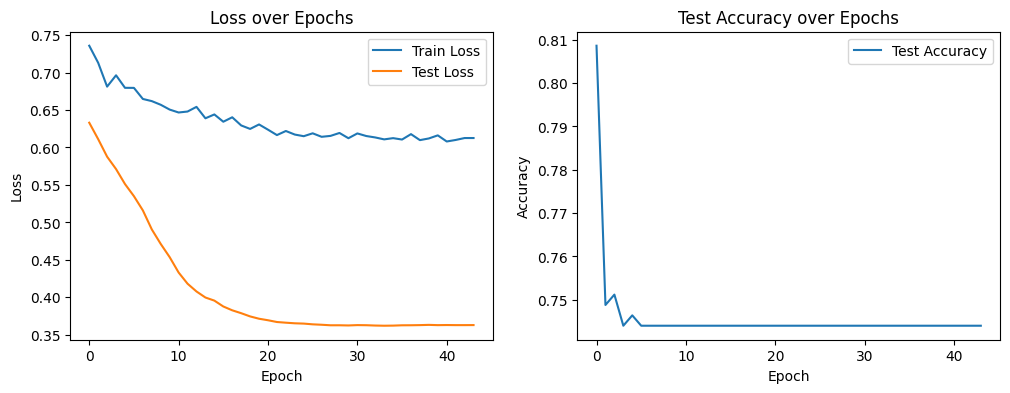

In [391]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.subplot(1,2,2)
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Test Accuracy over Epochs')
plt.show()

### Final Evaluation on Test Set

              precision    recall  f1-score   support

     No Loss       1.00      0.70      0.82       359
        Loss       0.36      1.00      0.52        59

    accuracy                           0.74       418
   macro avg       0.68      0.85      0.67       418
weighted avg       0.91      0.74      0.78       418



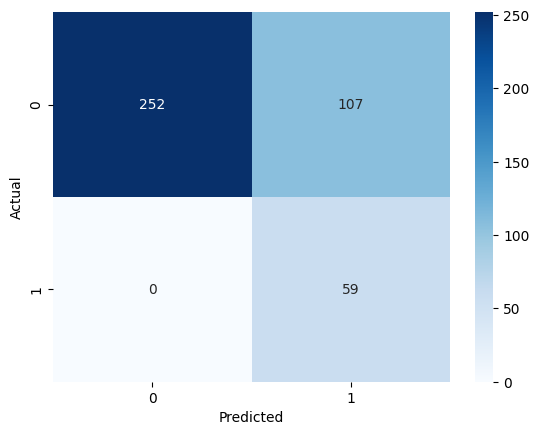

ROC-AUC: 0.8619


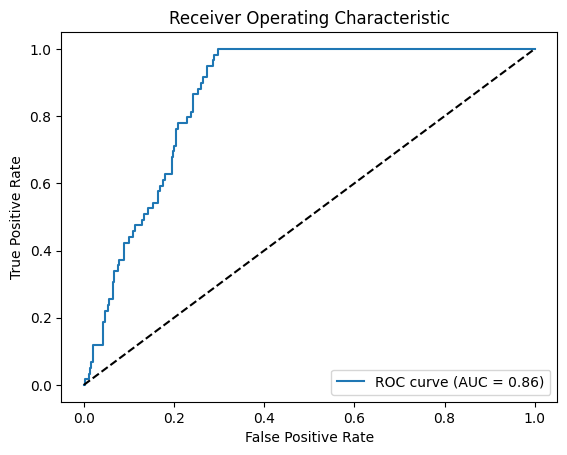

In [392]:
model.eval()
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()   # probability of class 1 (loss)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

# Classification report
print(classification_report(all_labels, all_preds, target_names=['No Loss', 'Loss']))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC-AUC
roc_auc = roc_auc_score(all_labels, all_probs)
print(f'ROC-AUC: {roc_auc:.4f}')

# ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend()
plt.show()

### Save the Trained Model

In [393]:
torch.save(model.state_dict(), 'forest_loss_nn.pth')
print('Model saved as forest_loss_nn.pth')

Model saved as forest_loss_nn.pth


# BIG ISSUE !!!!!!!!!!!!

### Getting dataset

In [394]:
train_dataset.features.shape[0]

1372

In [395]:
train_dataset.features.shape[1]

5

In [396]:
test_dataset.features.shape[0]

418

In [397]:
test_dataset.features.shape[1]

5